# Mapping the bike lanes and bike racks in Chapel Hill

This map is based on my own prefences for biking in Chapel Hill. I wanted to see where the bike lanes are and where bike racks are located. 

## Practice

Using another Chapel Hill geoJSON:

- download two geoJSONs from the Chapel Hill Server (not Stops, not the Boundary)
- inspect the type, shape, and columns
- select the name and geometry columns
- inspect the first geometry
- determine geometry types
- inspect the CRS
- filter the data
- make a copy of the result
- plot the selected features
- publish your work by uploading your JN to your GitHub (week06)

In [113]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [103]:
lanes = gpd.read_file("data/TOCH_Trails.geojson")
racks = gpd.read_file("data/Bicycle_Resource_Inventory_2020.geojson")

In [104]:
lanes.head()

,FID,FeatureTyp,Label,Fr_St,To_St,Notes,Shape_Leng,GlobalID,geometry
0,1,Sharrows,West Rosemary Street,Pritchard Avenue,Columbia Street,,291.971605,68dd959e-e845-46e3-80f6-7c90a329184e,"LINESTRING Z (-79.05727 35.9137 0, -79.05638 3..."
1,2,Sharrows,Ransom Street,W. Cameron Ave,S. Columbia St.,,2215.851974,1a95e6f5-24f4-4ef6-9c6f-2cdc99f05534,"LINESTRING Z (-79.05894 35.90896 0, -79.05894 ..."
2,3,Sharrows,W. Rosemary Street,Roberson Street,Henderson Street,,971.355236,e149be90-1324-4c14-b857-79a35838fb97,"LINESTRING Z (-79.05635 35.91404 0, -79.05626 ..."
3,4,Sharrows,Church Street,School Ln.,W. Franklin St.,Bike Boxes,2222.984089,af1e2e91-f075-4460-81ed-ccca49cb1bbd,"LINESTRING Z (-79.06134 35.91775 0, -79.06095 ..."
4,5,Sharrows,E. Rosemary Street,Columbia Street,Henderson Street,,973.998490,f1740445-5d8b-4c16-a08b-8d2f5b427879,"LINESTRING Z (-79.05636 35.91404 0, -79.05626 ..."


In [105]:
racks.head()

,OBJECTID,GlobalID,CreationDate,Creator,EditDate,Editor,ResourceType,ParkingType,Capacity,Condition,Lighting,WxProtect,LandUse,DistanceBusStop,Notes,Availability,AccessRating,VizRating,geometry
0,3,0179c95d-a9aa-46a9-9257-f5f495b62fa8,"Thu, 14 Jan 2021 21:01:55 GMT",epowell2_townofchapelhill,"Fri, 15 Jan 2021 15:52:35 GMT",dalmond,0,Double grid,10.0,Fair,No,No,Commercial,647.0,NaN,Public,Medium,Medium,POINT (-79.02679 35.92927)
1,4,ab0a224f-25c3-4641-adac-ea064a55ef87,"Thu, 14 Jan 2021 21:01:55 GMT",epowell2_townofchapelhill,"Fri, 15 Jan 2021 15:52:35 GMT",dalmond,0,Grid,7.0,Excellent,Yes,No,Commercial,1042.0,NaN,Public,Low,Low,POINT (-79.02528 35.92816)
2,5,b1e09332-20e9-4372-b55d-2452a8ad4d5b,"Thu, 14 Jan 2021 21:01:55 GMT",epowell2_townofchapelhill,"Fri, 15 Jan 2021 15:52:35 GMT",dalmond,0,Inverted U,8.0,Excellent,No,No,Commercial,1189.0,NaN,Public,Medium,Low,POINT (-79.02565 35.92756)
3,6,854f0b96-30f1-47f4-bdfc-874e0ea8e02b,"Thu, 14 Jan 2021 21:01:55 GMT",epowell2_townofchapelhill,"Fri, 15 Jan 2021 15:52:35 GMT",dalmond,0,Other,5.0,Excellent,Yes,No,Commercial,1120.0,NaN,Public,Medium,Low,POINT (-79.0259 35.92768)
4,7,677c4c6d-ce45-4147-ba78-7666397ea4af,"Thu, 14 Jan 2021 21:01:55 GMT",epowell2_townofchapelhill,"Fri, 15 Jan 2021 15:52:35 GMT",dalmond,0,Other,2.0,Fair,No,No,Commercial,892.0,NaN,Public,Medium,Low,POINT (-79.02687 35.92834)


In [83]:
type([lanes, racks])

list

In [84]:
print(lanes.shape, racks.shape)

(156, 9) (863, 19)


In [85]:
print(lanes.columns)
print(racks.columns)

Index(['FID', 'FeatureTyp', 'Label', 'Fr_St', 'To_St', 'Notes', 'Shape_Leng',
       'GlobalID', 'geometry'],
      dtype='str')
Index(['OBJECTID', 'GlobalID', 'CreationDate', 'Creator', 'EditDate', 'Editor',
       'ResourceType', 'ParkingType', 'Capacity', 'Condition', 'Lighting',
       'WxProtect', 'LandUse', 'DistanceBusStop', 'Notes', 'Availability',
       'AccessRating', 'VizRating', 'geometry'],
      dtype='str')


## Selecting columns

In [86]:
lanes = lanes[["FeatureTyp", "Label", "geometry"]]
lanes.head()

,FeatureTyp,Label,geometry
0,Sharrows,West Rosemary Street,"LINESTRING Z (-79.05727 35.9137 0, -79.05638 3..."
1,Sharrows,Ransom Street,"LINESTRING Z (-79.05894 35.90896 0, -79.05894 ..."
2,Sharrows,W. Rosemary Street,"LINESTRING Z (-79.05635 35.91404 0, -79.05626 ..."
3,Sharrows,Church Street,"LINESTRING Z (-79.06134 35.91775 0, -79.06095 ..."
4,Sharrows,E. Rosemary Street,"LINESTRING Z (-79.05636 35.91404 0, -79.05626 ..."


In [99]:
# Seeing what the options are for rack availability 
racks["Availability"].unique()

<StringArray>
['Public']
Length: 1, dtype: str

In [ ]:
# All fo the racks are public so don't need that column. 
racks = racks[["OBJECTID", "geometry"]]
racks.head()

,OBJECTID,geometry
0,3,POINT (1992067.186 793154.066)
1,4,POINT (1992515.104 792749.694)
2,5,POINT (1992407.266 792529.227)
3,6,POINT (1992330.892 792572.425)
4,7,POINT (1992044.958 792812.367)


## Inspecting the geometry

In [88]:
first_geom = lanes.geometry.iloc[0]
print(first_geom)
print(type(first_geom))

LINESTRING Z (-79.0572720167379 35.9136987039137 0, -79.0563778065495 35.91403666237 0)
<class 'shapely.geometry.linestring.LineString'>


In [89]:
first_geom = racks.geometry.iloc[0]
print(first_geom)
print(type(first_geom))

POINT (-79.0267947168113 35.9292744503141)
<class 'shapely.geometry.point.Point'>


In [90]:
lanes.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [91]:
racks.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [92]:
lanes = lanes.to_crs(epsg=6543)
racks = racks.to_crs(epsg=6543)
print(lanes.crs, racks.crs)

EPSG:6543 EPSG:6543


## Filtering the data

For the lanes dataset, keeping bikes lanes and paved greenways. Not keeping sharrows and unpaved greenways, because I do not like biking on those. 

In [ ]:
# .isin() is like %in% in R. 
lanes_filtered = lanes[lanes["FeatureTyp"].isin(["Bike Lane", "Paved Greenway"])].copy()
lanes.head()

,FeatureTyp,Label,geometry
6,Bike Lane,Weaver Dairy Rd.,"MULTILINESTRING Z ((1993634.367 802550.131 0, ..."
7,Bike Lane,Legion Road,"MULTILINESTRING Z ((1994912.798 796814.416 0, ..."
8,Bike Lane,Legion Road,"LINESTRING Z (1994548.191 796482.855 0, 199441..."
9,Bike Lane,Sage Road,"MULTILINESTRING Z ((1995086.925 801247.02 0, 1..."
10,Bike Lane,South Columbia Street,"MULTILINESTRING Z ((1982410.088 779403.478 0, ..."


In [ ]:
# Checking to make sure paved greenways were included since I'm not seeing any in the summary. 
paved_greenways = (lanes["FeatureTyp"] == "Paved Greenway").sum()
bike_lanes = (lanes["FeatureTyp"] == "Bike Lane").sum()

print(paved_greenways)
print(bike_lanes)

56
80


In [ ]:
racks_filtered = racks.copy()

# Plots

In [108]:
# TO DO: Ask about when to use .copy()
# TO DO: Make plots

<Axes: >

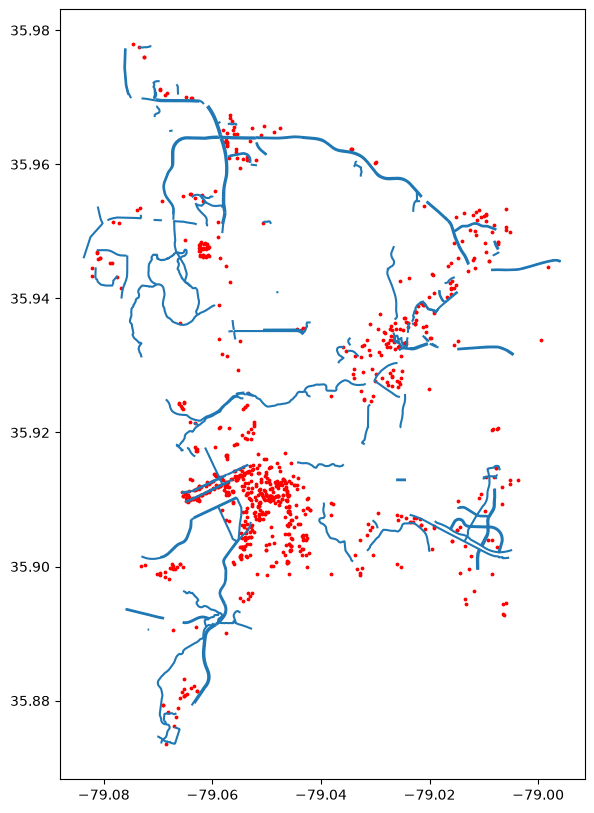

: 

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
# Automatically uses geometry column. 
lanes.plot(ax=ax)
racks.plot(ax=ax, markersize=3, c="red")